# Learn2Design 2026 — first data & landscape analysis

This notebook is deliberately exploratory. The goal is to understand the supplied UIFO data before committing to a model.

We start with:

1. dataset structure and topology reuse;
2. simple topology ↔ performance associations;
3. semantic parameter mappings (component/property rather than raw vector index);
4. elite parameter distributions;
5. a first **gradient-direction experiment** around known good designs.

The key question for the gradient test is:

> If we perturb a known good design, does the local gradient tend to point back toward that good basin?

Assumption: run this notebook from the root of the official `Learn2Design-2026` repository with `dataset/dataset.h5` present.

In [9]:
from __future__ import annotations

from pathlib import Path
import os

import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("JAX:", jax.__version__)
print("Devices:", jax.devices())

JAX: 0.9.0.1
Devices: [CpuDevice(id=0)]


## 1. Locate the dataset

Set `L2D_DATASET` if the notebook is not launched from the repository root.

In [10]:
REPO_ROOT = Path.cwd()
DATASET_PATH = Path(os.environ.get("L2D_DATASET", REPO_ROOT / "dataset.h5"))

print("Repository root:", REPO_ROOT)
print("Dataset:", DATASET_PATH)
print("Exists:", DATASET_PATH.exists())

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATASET_PATH}. Run from the Learn2Design-2026 repo root "
        "or set L2D_DATASET."
    )

Repository root: /home/jacob/code/Learn2Design-2026/dataset
Dataset: /home/jacob/code/Learn2Design-2026/dataset/dataset.h5
Exists: True


## 2. Read the HDF5 metadata lazily

The continuous parameter vectors are variable-length and stored in a flat pool. Initially we load only the small `entries` table.

In [11]:
def decode_h5_string(value) -> str:
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, (bytes, bytearray, np.bytes_)):
        return bytes(value).decode("utf-8", errors="replace").rstrip("\\x00")
    return str(value)


def entries_to_frame(handle: h5py.File) -> pd.DataFrame:
    rows = []
    for e in handle["entries"][:]:
        rows.append({
            "unique_hash": decode_h5_string(e["unique_hash"]),
            "initialized_from": decode_h5_string(e["initialized_from"]),
            "topology_string": decode_h5_string(e["topology_string"]),
            "size": int(e["size"]),
            "loss": float(e["loss"]),
            "complexity": int(e["complexity"]),
            "source_file": decode_h5_string(e["source_file"]),
            "run_id": decode_h5_string(e["run_id"]),
            "param_offset": int(e["param_offset"]),
            "param_length": int(e["param_length"]),
            "power_offset": int(e["power_offset"]),
            "power_length": int(e["power_length"]),
            "power_rows": int(e["power_rows"]),
            "power_cols": int(e["power_cols"]),
            "power_map_id": int(e["power_map_id"]),
        })
    return pd.DataFrame(rows)


with h5py.File(DATASET_PATH, "r") as h5:
    print("HDF5 datasets:")
    for key in h5.keys():
        obj = h5[key]
        print(f"  {key:30s} shape={getattr(obj, 'shape', None)} dtype={getattr(obj, 'dtype', None)}")
    designs = entries_to_frame(h5)

print("\\nNumber of designs:", len(designs))
print("Distinct topologies:", designs["topology_string"].nunique())
display(designs["size"].value_counts().sort_index().to_frame("count"))
display(designs.head())

HDF5 datasets:
  bounded_params                 shape=(5780308,) dtype=float64
  entries                        shape=(29650,) dtype=[('unique_hash', 'S24'), ('initialized_from', 'S24'), ('topology_string', 'S64'), ('param_offset', '<u8'), ('param_length', '<u4'), ('power_offset', '<u8'), ('power_length', '<u4'), ('power_rows', '<u4'), ('power_cols', '<u2'), ('power_map_id', '<u4'), ('size', '<u2'), ('loss', '<f8'), ('complexity', '<i4'), ('source_file', 'S96'), ('run_id', 'S16')]
  frequency_values               shape=(50,) dtype=float32
  power_port_map_indices         shape=(14800,) dtype=uint32
  power_port_map_names           shape=(14800,) dtype=|S25
  power_port_map_offsets         shape=(44,) dtype=uint32
  power_values                   shape=(8766524,) dtype=float32
  sensitivities                  shape=(29650, 50) dtype=float32
\nNumber of designs: 29650
Distinct topologies: 12437


,count
size,
3,28863
4,787


,unique_hash,initialized_from,topology_string,size,loss,complexity,source_file,run_id,param_offset,param_length,power_offset,power_length,power_rows,power_cols,power_map_id
0,a4486bd98582c3fb58f2b94b,,ABBGDGBEA-SLLLSDSLSLSL,3,0.496316,194,20251122-105858_59c52c21.h5,,0,194,0,286,286,1,0
1,3787880e602b69df6a0bae6f,,CDCCHDAFD-LDLSLSLLSLSL,3,0.597807,196,20251122-105858_59c52c21.h5,1,194,196,286,286,286,1,0
2,3aa18a58153451bafdd1e97f,,FAFACEHGH-LSLSLSLLDSSL,3,0.531372,185,20251122-105858_59c52c21.h5,2,390,185,572,286,286,1,0
3,7ab9fd9ed56a4b99a7ac513d,,FHDEAEGBE-LSLLHLSLSSLS,3,0.482505,187,20251122-105858_59c52c21.h5,3,575,187,858,296,296,1,1
4,f2d05b6d139a61990084b00d,,HFFABFACB-SLSSSLLSLSDL,3,0.761552,192,20251122-105858_59c52c21.h5,4,762,192,1154,286,286,1,0


## 3. Loss distribution and exact topology reuse

Topology reuse matters because a random row-level train/test split would leak topology information.

,loss
count,29650.000000
mean,1.458505
std,1.404974
min,-0.398996
1%,-0.231886
5%,0.253392
10%,0.377950
25%,0.431537
50%,0.709513
75%,2.255522


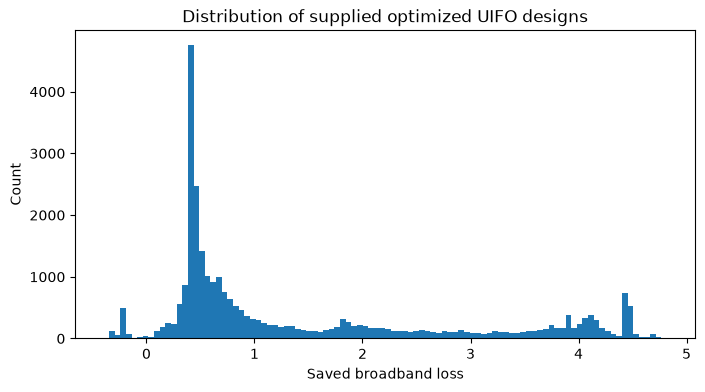

,n_designs
count,12437.000000
mean,2.384015
std,39.725669
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2878.000000


,size,topology_string,n_designs,best_loss,median_loss
4367,3,DABFEEGBB-SLSLLSLSSDLS,2878,-0.364817,0.427106
5157,3,DFACGAFAC-LSSSSLLSSDSS,1945,-0.072583,0.524798
1300,3,AHCGDCFAH-SLLSSHSLLLLS,1585,-0.287579,0.500025
2600,3,BGECGAADB-SSSSLLLLDLSL,1397,-0.201743,0.453545
10966,3,HEBCHEHBD-SSLLLSLLHSSS,1122,-0.273107,0.506055
9871,3,GGDBBGFAE-SHSSSSLSSSSL,1109,-0.230113,0.558267
8296,3,FFFHGHCAH-SSLLLLLLSSDS,509,-0.296322,-0.220998
3188,3,CBGEHECCH-SLLSHSLLLSLS,261,0.410146,0.415516
3109,3,CBDDDEBCC-LDLSSLSSSLLS,235,1.780253,3.917414
8402,3,FGDBDDGBF-LSSLLLSHLSLS,164,0.410945,0.415544


In [12]:
display(designs["loss"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(designs["loss"], bins=100)
ax.set_xlabel("Saved broadband loss")
ax.set_ylabel("Count")
ax.set_title("Distribution of supplied optimized UIFO designs")
plt.show()

reuse = (
    designs.groupby(["size", "topology_string"], as_index=False)
    .agg(n_designs=("unique_hash", "size"), best_loss=("loss", "min"), median_loss=("loss", "median"))
)

display(reuse["n_designs"].describe().to_frame())
display(reuse.sort_values(["n_designs", "best_loss"], ascending=[False, True]).head(20))

## 4. Decode topology strings

For 3×3 UIFO: 9 interior cells use `A-H` (ordinary/directional beamsplitter × orientation); 12 boundary cells use `L/S/D/H`.

In [13]:
CENTER_CODES = {
    "A": ("beamsplitter", "left"),
    "B": ("beamsplitter", "right"),
    "C": ("beamsplitter", "top"),
    "D": ("beamsplitter", "bottom"),
    "E": ("directional_beamsplitter", "left"),
    "F": ("directional_beamsplitter", "right"),
    "G": ("directional_beamsplitter", "top"),
    "H": ("directional_beamsplitter", "bottom"),
}
BOUNDARY_CODES = {"L": "laser", "S": "squeezer", "D": "detector", "H": "balanced_homodyne"}


def interior_positions(size: int) -> list[str]:
    return [f"{r}{c}" for r in range(1, size + 1) for c in range(1, size + 1)]


def boundary_positions(size: int) -> list[str]:
    grid = size + 2
    positions = [f"0{c}" for c in range(1, grid - 1)]
    for r in range(1, grid - 1):
        positions.extend([f"{r}0", f"{r}{grid - 1}"])
    positions.extend([f"{grid - 1}{c}" for c in range(1, grid - 1)])
    return positions


def decode_topology(topology: str, size: int):
    interior, boundary = topology.split("-")
    ipos, bpos = interior_positions(size), boundary_positions(size)
    centers = {p: CENTER_CODES[c] for p, c in zip(ipos, interior, strict=True)}
    boundaries = {p: BOUNDARY_CODES[c] for p, c in zip(bpos, boundary, strict=True)}
    return centers, boundaries


def topology_features(topology: str, size: int) -> dict:
    centers, boundaries = decode_topology(topology, size)
    out = {
        "n_beamsplitter": sum(c[0] == "beamsplitter" for c in centers.values()),
        "n_directional": sum(c[0] == "directional_beamsplitter" for c in centers.values()),
        "n_laser": sum(c == "laser" for c in boundaries.values()),
        "n_squeezer": sum(c == "squeezer" for c in boundaries.values()),
        "n_detector": sum(c == "detector" for c in boundaries.values()),
        "n_homodyne": sum(c == "balanced_homodyne" for c in boundaries.values()),
    }
    for pos, (component, orientation) in centers.items():
        out[f"center_{pos}_component"] = component
        out[f"center_{pos}_orientation"] = orientation
    for pos, component in boundaries.items():
        out[f"boundary_{pos}_component"] = component
    return out


topo_features = pd.DataFrame([
    topology_features(t, s) for t, s in zip(designs["topology_string"], designs["size"], strict=True)
], index=designs.index)
designs_aug = pd.concat([designs, topo_features], axis=1)
display(designs_aug.head())

,unique_hash,initialized_from,topology_string,size,loss,complexity,source_file,run_id,param_offset,param_length,power_offset,power_length,power_rows,power_cols,power_map_id,n_beamsplitter,n_directional,n_laser,n_squeezer,n_detector,n_homodyne,center_11_component,center_11_orientation,center_12_component,center_12_orientation,center_13_component,center_13_orientation,center_21_component,center_21_orientation,center_22_component,center_22_orientation,center_23_component,center_23_orientation,center_31_component,center_31_orientation,center_32_component,center_32_orientation,center_33_component,center_33_orientation,boundary_01_component,boundary_02_component,boundary_03_component,boundary_10_component,boundary_14_component,boundary_20_component,boundary_24_component,boundary_30_component,boundary_34_component,boundary_41_component,boundary_42_component,boundary_43_component,center_14_component,center_14_orientation,center_24_component,center_24_orientation,center_34_component,center_34_orientation,center_41_component,center_41_orientation,center_42_component,center_42_orientation,center_43_component,center_43_orientation,center_44_component,center_44_orientation,boundary_04_component,boundary_15_component,boundary_25_component,boundary_35_component,boundary_40_component,boundary_45_component,boundary_51_component,boundary_52_component,boundary_53_component,boundary_54_component
0,a4486bd98582c3fb58f2b94b,,ABBGDGBEA-SLLLSDSLSLSL,3,0.496316,194,20251122-105858_59c52c21.h5,,0,194,0,286,286,1,0,6,3,6,5,1,0,beamsplitter,left,beamsplitter,right,beamsplitter,right,directional_beamsplitter,top,beamsplitter,bottom,directional_beamsplitter,top,beamsplitter,right,directional_beamsplitter,left,beamsplitter,left,squeezer,laser,laser,laser,squeezer,detector,squeezer,laser,squeezer,laser,squeezer,laser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3787880e602b69df6a0bae6f,,CDCCHDAFD-LDLSLSLLSLSL,3,0.597807,196,20251122-105858_59c52c21.h5,1,194,196,286,286,286,1,0,7,2,7,4,1,0,beamsplitter,top,beamsplitter,bottom,beamsplitter,top,beamsplitter,top,directional_beamsplitter,bottom,beamsplitter,bottom,beamsplitter,left,directional_beamsplitter,right,beamsplitter,bottom,laser,detector,laser,squeezer,laser,squeezer,laser,laser,squeezer,laser,squeezer,laser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3aa18a58153451bafdd1e97f,,FAFACEHGH-LSLSLSLLDSSL,3,0.531372,185,20251122-105858_59c52c21.h5,2,390,185,572,286,286,1,0,3,6,6,5,1,0,directional_beamsplitter,right,beamsplitter,left,directional_beamsplitter,right,beamsplitter,left,beamsplitter,top,directional_beamsplitter,left,directional_beamsplitter,bottom,directional_beamsplitter,top,directional_beamsplitter,bottom,laser,squeezer,laser,squeezer,laser,squeezer,laser,laser,detector,squeezer,squeezer,laser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7ab9fd9ed56a4b99a7ac513d,,FHDEAEGBE-LSLLHLSLSSLS,3,0.482505,187,20251122-105858_59c52c21.h5,3,575,187,858,296,296,1,1,3,6,6,5,0,1,directional_beamsplitter,right,directional_beamsplitter,bottom,beamsplitter,bottom,directional_beamsplitter,left,beamsplitter,left,directional_beamsplitter,left,directional_beamsplitter,top,beamsplitter,right,directional_beamsplitter,left,laser,squeezer,laser,laser,balanced_homodyne,laser,squeezer,laser,squeezer,squeezer,laser,squeezer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f2d05b6d139a61990084b00d,,HFFABFACB-SLSSSLLSLSDL,3,0.761552,192,20251122-105858_59c52c21.h5,4,762,192,1154,286,286,1,0,5,4,5,6,1,0,directional_beamsplitter,bottom,directional_beamsplitter,right,directional_beamsplitter,right,beamsplitter,left,beamsplitter,right,directional_beamsplitter,right,beamsplitter,left,beamsplitter,top,beamsplitter,right,squeezer,laser,squeezer,squeezer,squeezer,laser,laser,squeezer,laser,squeezer,detector,laser,NaN,NaN,NaN,NaN,

## 5. First topology ↔ performance associations

Use one best observed design per exact topology to reduce repeated-topology bias. These are descriptive associations, not causal effects.

,count,mean,median,min
n_directional,,,,
0,19,1.997094,1.973610,0.299307
1,227,2.246594,2.152599,0.318767
2,756,2.363495,2.257518,0.187007
3,1939,2.135872,2.050519,-0.398996
4,2882,2.264056,2.167474,-0.364817
5,2853,2.265913,2.163745,-0.273107
6,1949,2.212283,2.053873,-0.244637
7,820,2.272079,2.130804,-0.296322
8,217,2.234007,1.995720,-0.129098


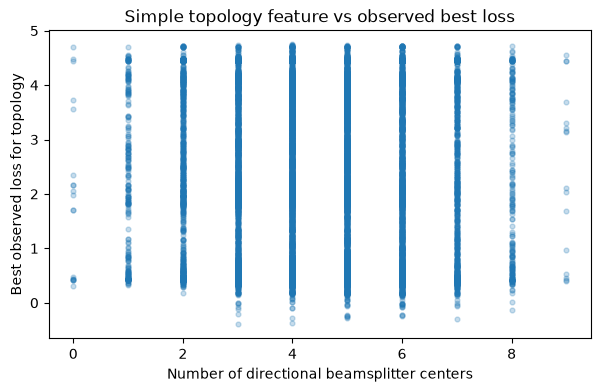

In [14]:
topology_level = designs_aug.sort_values("loss").drop_duplicates(["size", "topology_string"], keep="first")
t3 = topology_level[topology_level["size"] == 3].copy()

display(t3.groupby("n_directional")["loss"].agg(["count", "mean", "median", "min"]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(t3["n_directional"], t3["loss"], alpha=0.25, s=12)
ax.set_xlabel("Number of directional beamsplitter centers")
ax.set_ylabel("Best observed loss for topology")
ax.set_title("Simple topology feature vs observed best loss")
plt.show()

## 6. Reconstruct semantic parameter mappings

The raw parameter index is topology-dependent. We cache the official `optimization_pairs` mapping per exact topology and expand only a selected subset of designs.

In [15]:
from differometor.setups import constrain_inter_grid_cell_spaces, uifo
from dfbench.problems.uifo import topology_from_string

OPTIMIZED_PROPERTIES = ("reflectivity", "tuning", "db", "angle", "power", "mass", "length")


def reconstruct_optimization_pairs(topology_string: str, size: int):
    centers, boundaries = topology_from_string(topology_string, size)
    setup, _ = uifo(size=size, mode="space_modulation", random=True, centers=centers, boundaries=boundaries)
    return constrain_inter_grid_cell_spaces(setup.parameters, list(OPTIMIZED_PROPERTIES))


def targets_from_pair(pair):
    return [tuple(x) for x in pair] if isinstance(pair[0], list) else [tuple(pair)]


def property_from_pair(pair):
    return targets_from_pair(pair)[0][1]


_pair_cache = {}

def get_pairs(size, topology_string):
    key = (int(size), topology_string)
    if key not in _pair_cache:
        _pair_cache[key] = reconstruct_optimization_pairs(topology_string, int(size))
    return _pair_cache[key]


def load_params(handle, row):
    start = int(row["param_offset"])
    stop = start + int(row["param_length"])
    return np.asarray(handle["bounded_params"][start:stop])


def semanticize_design(handle, row):
    params = load_params(handle, row)
    pairs = get_pairs(row["size"], row["topology_string"])
    assert len(params) == len(pairs)
    records = []
    for i, (value, pair) in enumerate(zip(params, pairs, strict=True)):
        targets = targets_from_pair(pair)
        records.append({
            "unique_hash": row["unique_hash"],
            "topology_string": row["topology_string"],
            "loss": row["loss"],
            "param_index": i,
            "property": property_from_pair(pair),
            "value": float(value),
            "n_shared_targets": len(targets),
            "targets": targets,
            "primary_component": targets[0][0],
        })
    return pd.DataFrame(records)


N_PARAMETER_DESIGNS = 500
parameter_designs = designs.nsmallest(N_PARAMETER_DESIGNS, "loss")
with h5py.File(DATASET_PATH, "r") as h5:
    semantic_params = pd.concat(
        [semanticize_design(h5, row) for _, row in parameter_designs.iterrows()],
        ignore_index=True,
    )

print("Semantic rows:", len(semantic_params))
print("Cached topologies:", len(_pair_cache))
display(semantic_params.head(20))

Semantic rows: 93429
Cached topologies: 11


,unique_hash,topology_string,loss,param_index,property,value,n_shared_targets,targets,primary_component
0,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,0,reflectivity,9.998588e-01,1,"[(center11, reflectivity)]",center11
1,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,1,tuning,-3.600000e+02,1,"[(center11, tuning)]",center11
2,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,2,mass,1.000000e-02,1,"[(center11sus, mass)]",center11sus
3,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,3,reflectivity,8.843775e-08,1,"[(ml11, reflectivity)]",ml11
4,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,4,tuning,-3.599965e+02,1,"[(ml11, tuning)]",ml11
5,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,5,reflectivity,4.004474e-13,1,"[(mr11, reflectivity)]",mr11
6,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,6,tuning,-3.600000e+02,1,"[(mr11, tuning)]",mr11
7,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,7,reflectivity,6.035707e-08,1,"[(mt11, reflectivity)]",mt11
8,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,8,tuning,-3.599999e+02,1,"[(mt11, tuning)]",mt11
9,2a2fa296d5804b72e7e3fd07,CDAGBFAHB-LSHSSLSSSLLS,-0.398996,9,reflectivity,1.687741e-09,1,"[(mb11, reflectivity)]",mb11


## 7. Elite parameter distributions

This is intentionally pooled for the first look. The next refinement is to condition by component type, position, local neighbourhood, and design quality.

,count,mean,std,min,1%,5%,50%,95%,99%,max
property,,,,,,,,,,
angle,2739.0,129.088768,129.525571,4.161963e-07,6.442285e-02,2.900574e-01,89.999999,359.913227,359.999923,359.999923
db,2739.0,2.319185,3.897349,7.674691e-06,6.616748e-05,7.823438e-05,0.005466,9.996102,9.996149,10.000000
length,8000.0,1497.056481,1868.640228,1.000000e-01,1.000000e-01,1.000000e-01,4.364117,4000.000000,4000.000000,4000.000000
mass,25724.0,150.181381,81.857893,1.000000e-02,1.000000e-02,1.000000e-02,199.895749,200.000000,200.000000,200.000000
power,2761.0,89.587803,80.556861,5.402780e-10,4.546654e-08,5.491136e-07,79.265795,199.999564,199.999987,199.999998
reflectivity,25733.0,0.586656,0.475301,5.857997e-21,2.606271e-18,1.814882e-15,0.988676,1.000000,1.000000,1.000000
tuning,25733.0,35.577162,327.959259,-3.600000e+02,-3.600000e+02,-3.600000e+02,0.879852,360.000000,360.000000,360.000000


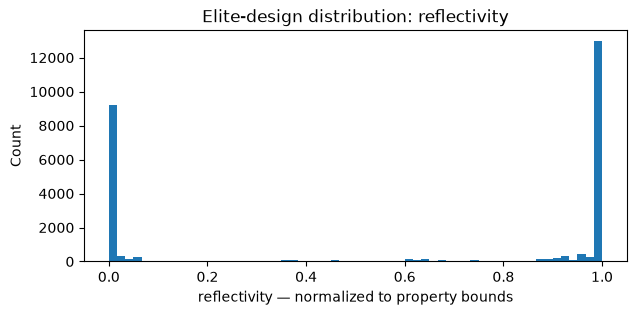

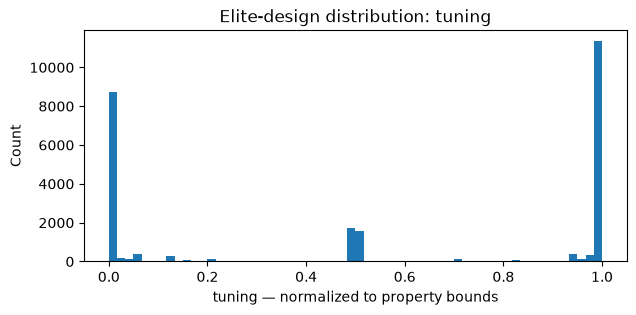

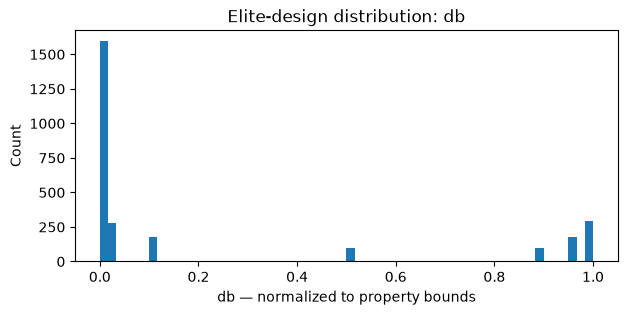

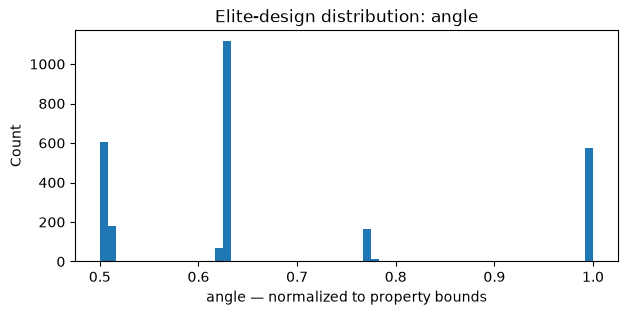

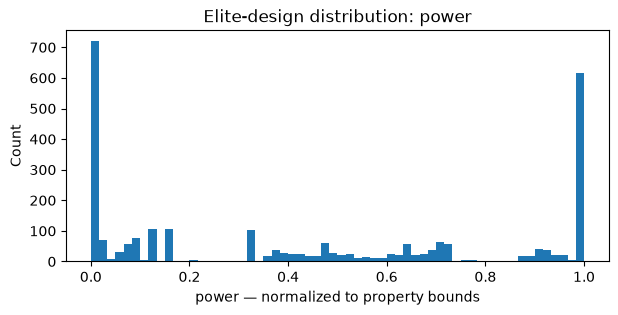

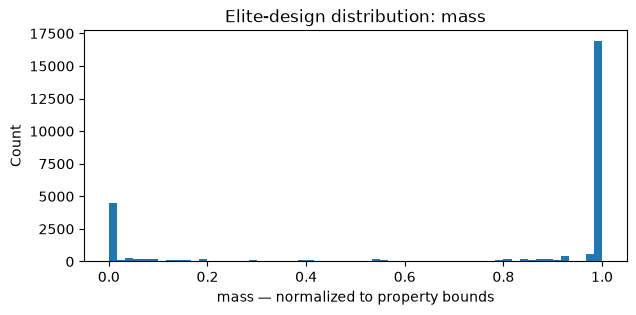

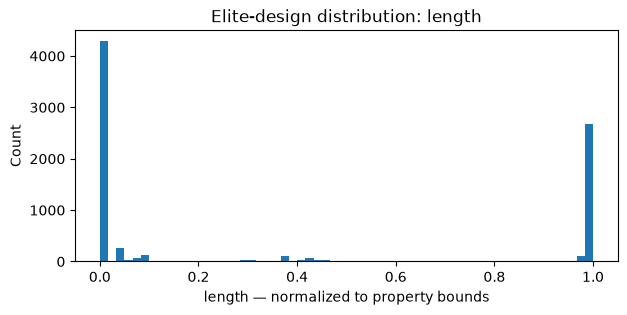

In [16]:
PROPERTY_BOUNDS = {
    "db": (0.0, 10.0), "angle": (-360.0, 360.0), "power": (0.0, 200.0),
    "tuning": (-360.0, 360.0), "mass": (0.01, 200.0), "length": (0.1, 4000.0),
    "reflectivity": (0.0, 1.0),
}

semantic_params["normalized_value"] = [
    (v - PROPERTY_BOUNDS[p][0]) / (PROPERTY_BOUNDS[p][1] - PROPERTY_BOUNDS[p][0])
    for p, v in zip(semantic_params["property"], semantic_params["value"], strict=True)
]

display(semantic_params.groupby("property")["value"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

for prop in OPTIMIZED_PROPERTIES:
    values = semantic_params.loc[semantic_params["property"] == prop, "normalized_value"].dropna()
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(values, bins=60)
    ax.set_xlabel(f"{prop} — normalized to property bounds")
    ax.set_ylabel("Count")
    ax.set_title(f"Elite-design distribution: {prop}")
    plt.show()

### Reflectivity endpoints

A specific hypothesis is that values close to 0 or 1 effectively suppress or seal optical paths, producing an *effective* topology inside the fixed nominal topology.

R <= 0.02:       0.367
R >= 0.98:     0.505
middle:                  0.128


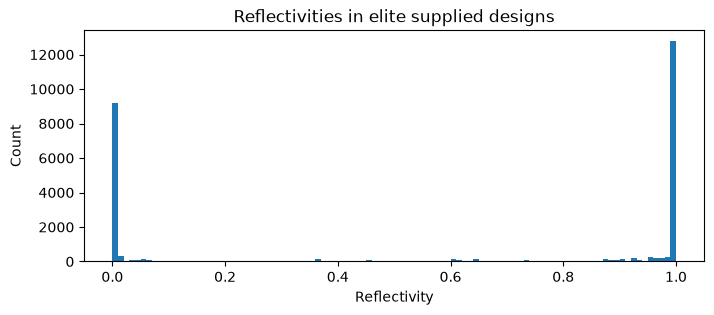

In [17]:
r = semantic_params.loc[semantic_params["property"] == "reflectivity", "value"]
threshold = 0.02
print(f"R <= {threshold}:       {(r <= threshold).mean():.3f}")
print(f"R >= {1-threshold}:     {(r >= 1-threshold).mean():.3f}")
print(f"middle:                  {((r > threshold) & (r < 1-threshold)).mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(r, bins=100)
ax.set_xlabel("Reflectivity")
ax.set_ylabel("Count")
ax.set_title("Reflectivities in elite supplied designs")
plt.show()

## 8. Gradient-direction experiment

For a known good design \(x^\star\):

1. normalize parameters to \([0,1]\) using topology-specific bounds;
2. perturb by a controlled normalized radius;
3. evaluate the objective and gradient at the perturbed point \(x\);
4. transform the gradient into normalized coordinates;
5. measure

\[
\cos\left(-\nabla_x L(x),\,x^\star-x\right).
\]

Interpretation: +1 points directly toward the known good design, 0 is unrelated, -1 points directly away.

Caveat: a supplied solution is a known good point, not necessarily the global optimum. Therefore we also test whether a small normalized gradient step lowers the objective.

In [18]:
from dfbench.problems import UIFOProblem


def load_design_params(row):
    with h5py.File(DATASET_PATH, "r") as h5:
        return load_params(h5, row)


def cosine_similarity(a, b, eps=1e-12):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < eps or nb < eps:
        return np.nan
    return float(np.dot(a, b) / (na * nb))


def gradient_direction_experiment(
    row,
    radii=(0.005, 0.01, 0.03, 0.10, 0.20),
    n_directions=8,
    gradient_step=0.01,
    seed=0,
):
    rng = np.random.default_rng(seed)
    problem = UIFOProblem(size=int(row["size"]), topology=row["topology_string"], n_frequencies=50)

    theta_star = np.asarray(load_design_params(row), dtype=float)
    lower = np.asarray(problem.bounds[0], dtype=float)
    upper = np.asarray(problem.bounds[1], dtype=float)
    scale = upper - lower
    assert len(theta_star) == problem.n_params

    x_star = (theta_star - lower) / scale
    value_and_grad = jax.jit(jax.value_and_grad(problem.objective_function))

    theta_star_jax = jnp.asarray(theta_star)
    star_loss = float(problem.objective_function(theta_star_jax).block_until_ready())
    _ = value_and_grad(theta_star_jax)  # compile

    records = []
    for radius in radii:
        for direction_id in range(n_directions):
            direction = rng.normal(size=problem.n_params)
            direction /= np.linalg.norm(direction)

            x = np.clip(x_star + radius * direction, 1e-6, 1 - 1e-6)
            theta = jnp.asarray(lower + x * scale)

            loss, grad_theta = value_and_grad(theta)
            loss = float(loss)
            grad_x = np.asarray(grad_theta) * scale  # chain rule

            descent = -grad_x
            toward_star = x_star - x
            cosine = cosine_similarity(descent, toward_star)

            grad_norm = np.linalg.norm(grad_x)
            if np.isfinite(grad_norm) and grad_norm > 0:
                x_step = np.clip(x - gradient_step * grad_x / grad_norm, 1e-6, 1 - 1e-6)
                step_loss = float(problem.objective_function(jnp.asarray(lower + x_step * scale)).block_until_ready())
            else:
                step_loss = np.nan

            records.append({
                "hash": row["unique_hash"],
                "topology": row["topology_string"],
                "saved_loss": float(row["loss"]),
                "recomputed_star_loss": star_loss,
                "radius": radius,
                "direction_id": direction_id,
                "distance_after_clipping": float(np.linalg.norm(x - x_star)),
                "perturbed_loss": loss,
                "cosine_to_known_optimum": cosine,
                "normalized_grad_norm": float(grad_norm),
                "gradient_step_loss": step_loss,
                "gradient_step_improved": step_loss < loss,
            })
    return pd.DataFrame(records)

### Run first on one strong 3×3 design

The first call can be slow because JAX compiles the UIFO objective.

In [ ]:
candidate = designs.loc[designs["size"] == 3].sort_values("loss").iloc[0]
display(candidate[["unique_hash", "topology_string", "loss", "complexity", "param_length"]].to_frame("value"))

gradient_results = gradient_direction_experiment(
    candidate,
    radii=(0.005, 0.01, 0.03, 0.10, 0.20),
    n_directions=8,
    gradient_step=0.01,
    seed=42,
)
display(gradient_results.head())

,value
unique_hash,2a2fa296d5804b72e7e3fd07
topology_string,CDAGBFAHB-LSHSSLSSSLLS
loss,-0.398996
complexity,198
param_length,198


In [ ]:
gradient_summary = gradient_results.groupby("radius").agg(
    n=("cosine_to_known_optimum", "size"),
    mean_cosine=("cosine_to_known_optimum", "mean"),
    median_cosine=("cosine_to_known_optimum", "median"),
    positive_cosine_fraction=("cosine_to_known_optimum", lambda x: np.mean(x > 0)),
    gradient_step_success=("gradient_step_improved", "mean"),
    mean_loss=("perturbed_loss", "mean"),
)
display(gradient_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0.0, linewidth=1)
ax.plot(gradient_summary.index, gradient_summary["mean_cosine"], marker="o", label="Mean")
ax.plot(gradient_summary.index, gradient_summary["median_cosine"], marker="o", label="Median")
ax.set_xscale("log")
ax.set_xlabel("Perturbation radius in normalized parameter space")
ax.set_ylabel("cos(-grad L, direction to known optimum)")
ax.set_title("Does the gradient point toward a known good basin?")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gradient_summary.index, gradient_summary["gradient_step_success"], marker="o")
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("Perturbation radius in normalized parameter space")
ax.set_ylabel("Fraction where one gradient step lowers loss")
ax.set_title("Local usefulness of the gradient")
plt.show()

## 9. Multi-topology extension

Only run this after the one-topology test behaves sensibly. Each new topology may require a separate JAX compilation.

In [ ]:
N_GRADIENT_TOPOLOGIES = 5

gradient_candidates = (
    designs.loc[designs["size"] == 3]
    .sort_values("loss")
    .drop_duplicates("topology_string")
    .head(N_GRADIENT_TOPOLOGIES)
)

# all_gradient_results = []
# for i, (_, row) in enumerate(gradient_candidates.iterrows()):
#     print(f"[{i+1}/{len(gradient_candidates)}] loss={row['loss']:.4f} topology={row['topology_string']}")
#     result = gradient_direction_experiment(
#         row,
#         radii=(0.005, 0.01, 0.03, 0.10, 0.20),
#         n_directions=8,
#         gradient_step=0.01,
#         seed=100 + i,
#     )
#     all_gradient_results.append(result)
#
# all_gradient_results = pd.concat(all_gradient_results, ignore_index=True)
# display(all_gradient_results.groupby("radius").agg(
#     mean_cosine=("cosine_to_known_optimum", "mean"),
#     median_cosine=("cosine_to_known_optimum", "median"),
#     positive_cosine_fraction=("cosine_to_known_optimum", lambda x: np.mean(x > 0)),
#     gradient_step_success=("gradient_step_improved", "mean"),
# ))

## 10. Next additions to this same notebook

After looking at the first outputs, the next analyses should be driven by what the data says:

- component/context-conditioned parameter distributions;
- elite-vs-non-elite local motif enrichment;
- effective topology from reflectivity + optical power;
- Hessian interaction strength aggregated by graph distance;
- gradient tests by property type and from random points;
- feasibility-aware gradient diagnostics;
- actual Adam trajectories and whether their early gradients predict which basin they reach.

The Hessian analysis is particularly useful for directly testing whether the landscape is approximately local/block-structured.